## Import Library And Load Data


In [1]:
import pandas as pd

df = pd.read_csv(r"M:\archive (1)\product_sales_dataset_final.csv")
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Convert date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Sort data
df = df.sort_values('Order_Date')

# Check columns
df.columns
df


C:\Users\Owner\AppData\Local\Temp\ipykernel_9480\3966898828.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
178788,178789,2023-01-01,Mark Davis,Newark,New Jersey,East,United States,Electronics,Home Appliances,KitchenAid Mixer,4,748.71,2994.84,412.51
100472,100473,2023-01-01,Jordan Martin,Sioux Falls,South Dakota,Centre,United States,Clothing & Apparel,Men's Wear,GAP Hoodie,2,346.47,692.94,176.38
50253,50254,2023-01-01,Kimberly Branch,Philadelphia,Pennsylvania,East,United States,Clothing & Apparel,Kids Wear,Carter's Onesie,1,223.49,223.49,55.93
135646,135647,2023-01-01,Debra Anderson,Fargo,North Dakota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,5,247.90,1239.50,510.08
77523,77524,2023-01-01,Kristen Barton,Santa Fe,New Mexico,West,United States,Accessories,Bags,Backpack,1,76.58,76.58,36.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189907,189908,2024-12-31,Gary Barnes,San Antonio,Texas,South,United States,Accessories,Small Electronics,Phone Case,2,174.53,349.06,138.71
145257,145258,2024-12-31,Richard Green,Baltimore,Maryland,East,United States,Home & Furniture,Storage,Storage Rack,1,115.39,115.39,31.12
190793,190794,2024-12-31,Alicia David,Montpelier,Vermont,East,United States,Home & Furniture,Home Decor,Throw Pillows,1,244.65,244.65,33.25
56717,56718,2024-12-31,Jeremiah Hall,Las Vegas,Nevada,West,United States,Home & Furniture,Home Decor,Throw Pillows,3,882.64,2647.92,788.13


## Grouping Date

In [2]:
daily_df = df.groupby('Order_Date')['Revenue'].sum().reset_index()
daily_df

,Order_Date,Revenue
0,2023-01-01,165963.02
1,2023-01-02,140628.67
2,2023-01-03,117087.84
3,2023-01-04,131121.99
4,2023-01-05,131237.15
...,...,...
726,2024-12-27,341364.65
727,2024-12-28,283250.74
728,2024-12-29,343199.96
729,2024-12-30,293935.92


## Extract Day, Month, Year, DayOfWeek


In [3]:
daily_df['day'] = daily_df['Order_Date'].dt.day
daily_df['month'] = daily_df['Order_Date'].dt.month
daily_df['year'] = daily_df['Order_Date'].dt.year
daily_df['day_of_week'] = daily_df['Order_Date'].dt.dayofweek

In [4]:
# Lag features
daily_df['lag_1'] = daily_df['Revenue'].shift(1)
daily_df['lag_7'] = daily_df['Revenue'].shift(7)
daily_df['lag_14'] = daily_df['Revenue'].shift(14)
daily_df['lag_30'] = daily_df['Revenue'].shift(30)

# Rolling features 
daily_df['rolling_mean_7'] = daily_df['Revenue'].rolling(7).mean()
daily_df['rolling_mean_14'] = daily_df['Revenue'].rolling(14).mean()

daily_df['rolling_std_7'] = daily_df['Revenue'].rolling(7).std()
daily_df['rolling_mean_3'] = daily_df['Revenue'].rolling(3).mean()


In [5]:
daily_df = daily_df.dropna()
daily_df

,Order_Date,Revenue,day,month,year,day_of_week,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_mean_3
30,2023-01-31,136270.74,31,1,2023,1,129632.91,137100.38,128337.19,165963.02,140366.547143,141216.207857,12313.113288,133138.333333
31,2023-02-01,77896.07,1,2,2023,2,136270.74,144392.41,154520.32,140628.67,130867.070000,135743.047143,26344.983817,114599.906667
32,2023-02-02,81566.17,2,2,2023,3,77896.07,129322.68,116938.73,117087.84,124044.711429,133216.435714,32318.030568,98577.660000
33,2023-02-03,110557.84,3,2,2023,4,81566.17,145215.22,146230.96,131121.99,119093.657143,130668.355714,31168.481133,90006.693333
34,2023-02-04,104211.23,4,2,2023,5,110557.84,164220.52,151203.50,131237.15,110520.901429,127311.765000,24150.407862,98778.413333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2024-12-27,341364.65,27,12,2024,4,289768.94,310369.48,309192.42,345446.77,328435.745714,332173.511429,34816.596752,312192.036667
727,2024-12-28,283250.74,28,12,2024,5,341364.65,344582.32,392376.12,311407.47,319674.091429,324378.841429,37675.764172,304794.776667
728,2024-12-29,343199.96,29,12,2024,6,283250.74,392534.52,374145.56,724778.58,312626.297143,322168.441429,23853.384966,322605.116667
729,2024-12-30,293935.92,30,12,2024,0,343199.96,323077.38,338533.69,417730.19,308463.231429,318982.886429,24264.827419,306795.540000


In [6]:
X = daily_df.drop(['Order_Date', 'Revenue'], axis=1)
y = daily_df['Revenue']

In [7]:
split = int(len(daily_df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 24151.018991489316
R2: 0.8973055833526733


In [10]:
results = pd.DataFrame({
    'Order_Date': daily_df['Order_Date'][split:],
    'Actual': y_test,
    'Predicted': y_pred,
    'Diff': y_test - y_pred
})

results.head(51)

,Order_Date,Actual,Predicted,Diff
590,2024-08-13,130297.00,131615.41230,-1318.41230
591,2024-08-14,125864.26,119048.66030,6815.59970
592,2024-08-15,157303.38,141282.89305,16020.48695
593,2024-08-16,154535.27,153168.12915,1367.14085
594,2024-08-17,156325.48,160841.17970,-4515.69970
595,2024-08-18,154103.25,161725.88480,-7622.63480
596,2024-08-19,160665.08,147940.71565,12724.36435
597,2024-08-20,124242.62,137135.21760,-12892.59760
598,2024-08-21,145890.99,145807.90225,83.08775
599,2024-08-22,132814.50,131474.68255,1339.81745


In [11]:
# Reset
future_preds = []

future_days = 30
history = list(daily_df['Revenue'].values)
last_date = daily_df['Order_Date'].iloc[-1]

for i in range(future_days):

    next_date = last_date + pd.Timedelta(days=1)

    new_row = {
    'day': next_date.day,
    'month': next_date.month,
    'year': next_date.year,
    'day_of_week': next_date.dayofweek,
    'lag_1': history[-1],
    'lag_7': history[-7],
    'lag_14': history[-14],
    'lag_30': history[-30],
    'rolling_mean_3': sum(history[-3:]) / 3,
    'rolling_mean_7': sum(history[-7:]) / 7,
    'rolling_mean_14': sum(history[-14:]) / 14,
    'rolling_std_7': pd.Series(history[-7:]).std()
}
    new_df = pd.DataFrame([new_row])
    new_df = new_df[X.columns]
    pred = model.predict(new_df)[0]

    future_preds.append(pred)
    history.append(pred)
    last_date = next_date

In [12]:
future_dates = pd.date_range(
    start=daily_df['Order_Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Revenue': future_preds
})

In [13]:
future_df

,Date,Predicted_Revenue
0,2025-01-01,180438.61655
1,2025-01-02,172501.49700
2,2025-01-03,195190.16270
3,2025-01-04,183518.75000
4,2025-01-05,182057.92740
5,2025-01-06,149445.29655
6,2025-01-07,146809.39040
7,2025-01-08,155234.25975
8,2025-01-09,152750.30340
9,2025-01-10,162666.51255


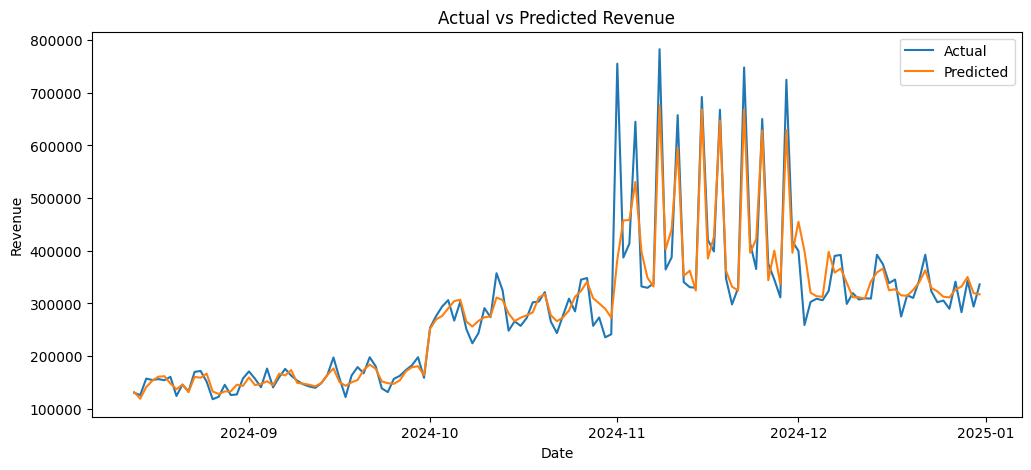

In [14]:
import matplotlib.pyplot as plt

# Create comparison dataframe
comparison = pd.DataFrame({
    'Date': daily_df['Order_Date'][split:],
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Plot
plt.figure(figsize=(12,5))

plt.plot(comparison['Date'], comparison['Actual'], label='Actual')
plt.plot(comparison['Date'], comparison['Predicted'], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

## XGBoost Model 


In [15]:
from xgboost import XGBRegressor

In [16]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 22037.34576906028
R2: 0.9075736732618988


In [19]:
results = pd.DataFrame({
    'Order_Date': daily_df['Order_Date'][split:],
    'Actual': y_test,
    'Predicted': y_pred,
    'Diff': y_test - y_pred
})

results.head(51)

,Order_Date,Actual,Predicted,Diff
590,2024-08-13,130297.00,130448.539062,-151.539062
591,2024-08-14,125864.26,120511.656250,5352.603750
592,2024-08-15,157303.38,141635.921875,15667.458125
593,2024-08-16,154535.27,152430.390625,2104.879375
594,2024-08-17,156325.48,157539.281250,-1213.801250
595,2024-08-18,154103.25,158288.734375,-4185.484375
596,2024-08-19,160665.08,149685.109375,10979.970625
597,2024-08-20,124242.62,135398.515625,-11155.895625
598,2024-08-21,145890.99,148634.187500,-2743.197500
599,2024-08-22,132814.50,126018.679688,6795.820312


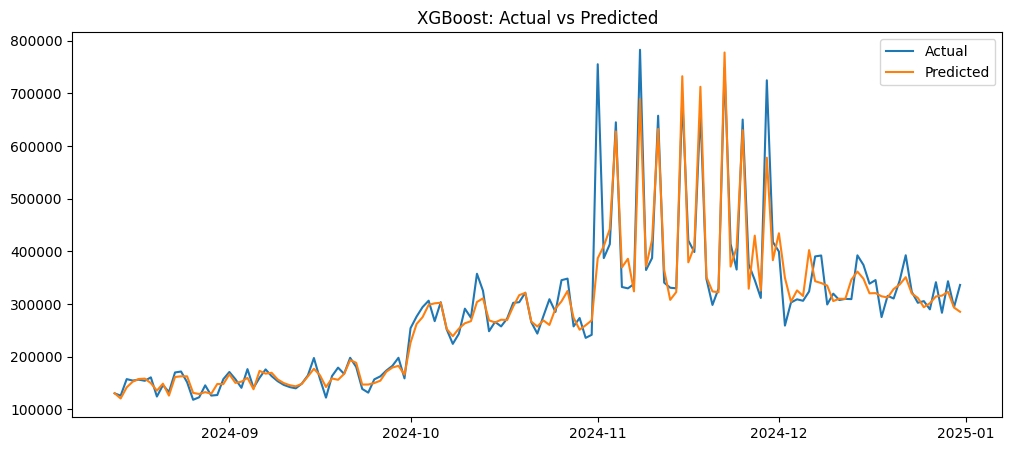

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(daily_df['Order_Date'][split:], y_test.values, label='Actual')
plt.plot(daily_df['Order_Date'][split:], y_pred, label='Predicted')

plt.legend()
plt.title("XGBoost: Actual vs Predicted")
plt.show()